# Multi-armed bandit algorithm

Madison Buitenhuis, Frankie Chen, Patrick Devine

In [1]:
# Import necessary packages
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Initialize a bandit machine where you can input the number of arms
class bandit_machine:
  def __init__(self, n_arms):
    self.n_arms = n_arms
    self.true_vals = np.random.normal(size=n_arms)
    self.arms_std = np.full(n_arms,1)

  def pull(self, arm):
    return np.random.normal(self.true_vals[arm], self.arms_std[arm])


In [3]:
# Define the epsilon-greedy algorithm to search for a solution

def epsilon_greedy(bandit, steps, epsilon):
  # Initiate our arrays for storing info
  estimated_vals = np.zeros(bandit.n_arms)
  num_pulls = np.zeros(bandit.n_arms)
  optimal = np.zeros(steps)
  rewards = []

  for i in range(steps):
    # Implement the epsilon method
    if np.random.random() < epsilon:
      arm = np.random.choice(bandit.n_arms)

    else:
      arm = np.argmax(estimated_vals)

    # Pull the designated arm
    reward = bandit.pull(arm)
    num_pulls[arm] += 1
    rewards.append(reward)

    # Store if the action was optimal
    if arm == np.argmax(bandit.true_vals):
      optimal[i] += 1

    # Update estimated values
    estimated_vals[arm] += (reward - estimated_vals[arm]) / num_pulls[arm]

  return rewards, optimal



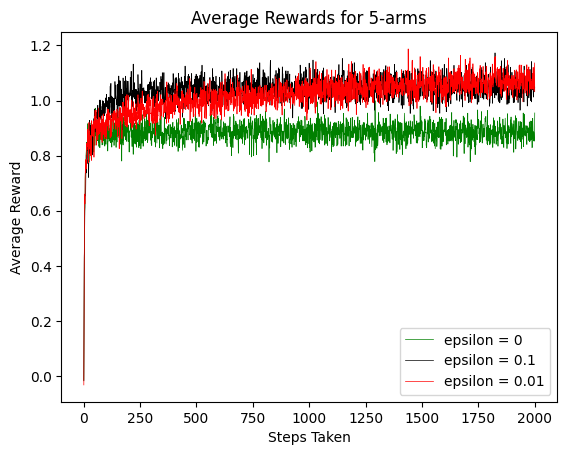

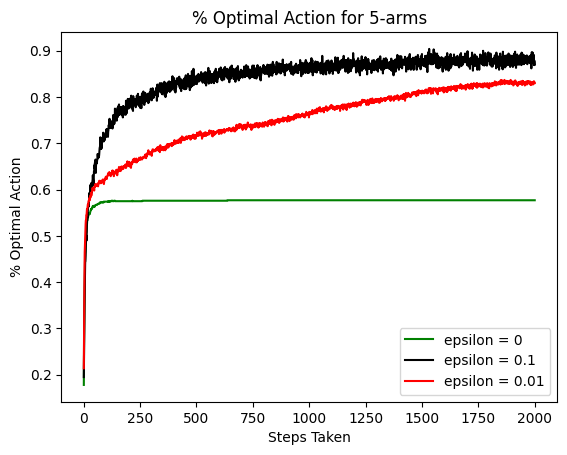

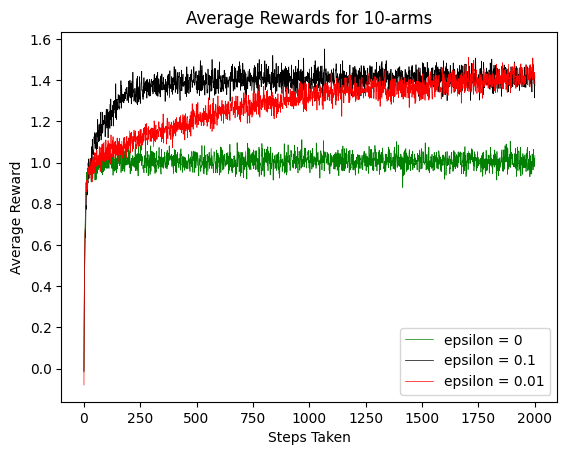

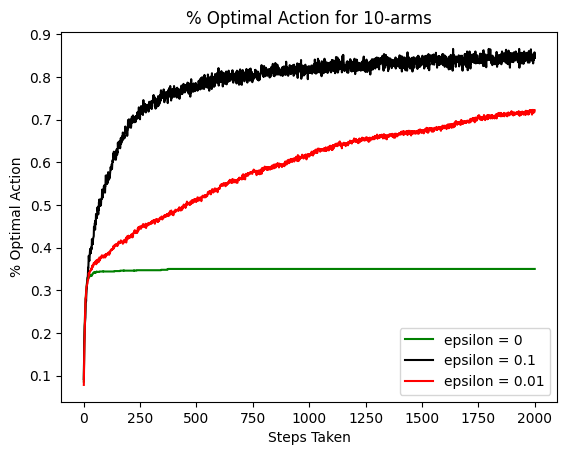

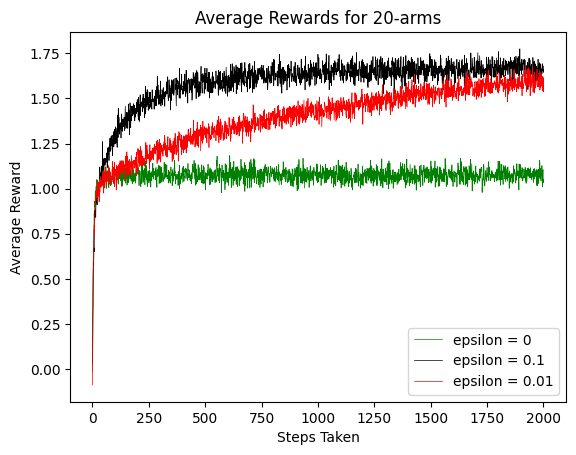

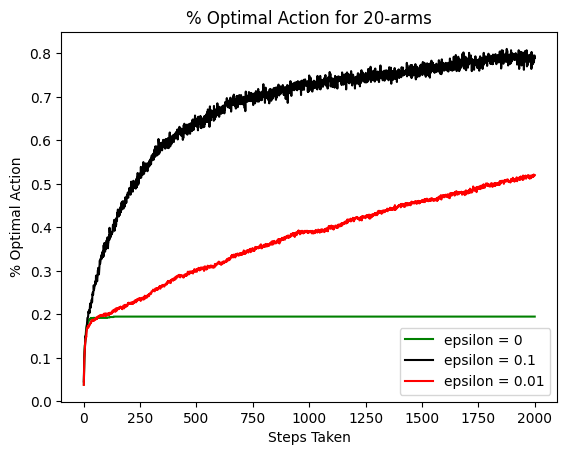

In [4]:
# define number of bandits to be run
num_bandit = 1000

# define the number of steps
N = 2000

# define an array containing the possible number of arms
n_vals = [5, 10, 20]

# Define epsilon values to evaluate (note that epislon = 0 is the regular greedy algorithm)
epsilon = [0, 0.1, 0.01]

# Create a x-vals for our plots
x_vals = np.arange(1,N + 1)

# Create a colour array for our plots
colours = ['g', 'k', 'r']

for n in n_vals:
  # Create index to iterate through line colours
  c = 0

  # Create figures for two plots per arm number
  fig1 = plt.figure(1)
  fig2 = plt.figure(2)

  # Iteratae through epsilon values for each n
  for e in epsilon:

    # Store the outputs for each bandit ran
    y_reward = []
    y_optimal = []
    for i in range(num_bandit):
      bandit = bandit_machine(n)
      reward, optimal = epsilon_greedy(bandit, N, e)
      y_reward.append(reward)
      y_optimal.append(optimal)

    # Calculate average reward and optimal values over num_bandits
    reward_avg = np.average(y_reward, axis=0)
    optimal_avg = np.average(y_optimal, axis=0)

    # Plot outcomes
    iter = "epsilon = {}".format(e)
    plt.figure(1)
    plt.plot(x_vals, reward_avg, label = iter, linewidth=0.5, color=colours[c])

    plt.figure(2)
    plt.plot(x_vals, optimal_avg, label = iter, color=colours[c])
    c += 1

  # Finalise and show plots
  plt.figure(1)
  plt.title(f'Average Rewards for {n}-arms')
  plt.xlabel('Steps Taken')
  plt.ylabel('Average Reward')
  plt.legend()

  plt.figure(2)
  plt.title(f'% Optimal Action for {n}-arms')
  plt.xlabel('Steps Taken')
  plt.ylabel('% Optimal Action')
  plt.legend()
  plt.show()